# 01 – Exploratory Data Analysis (EDA)

**Goal:** understand the TED data before modelling and turn what we see into concrete decisions for the later phases.

Each section answers one question and ends with **Findings** (what we saw) and, where relevant, a **Decision** (what we will do).
All decisions are summarised at the end and in `docs/data_notes.md`.

Input: `data/processed/talks.parquet` (built by `python -m src.prepare_data`).

## 0. Load the data

In [46]:
import sys
sys.path.append("..")          # lets the notebook find the src/ folder

import matplotlib.pyplot as plt
import pandas as pd
from src.config import TALKS_FILE

pd.set_option("display.max_colwidth", None)   # show full text in table cells

df = pd.read_parquet(TALKS_FILE)               # one row per talk, already cleaned

## 1. Overview and missing values

In [47]:
print("DF shape:", df.shape)
df.info()                      # column types and non-null counts
print(df.isna().sum())         # missing values per column

DF shape: (2427, 17)
<class 'pandas.DataFrame'>
RangeIndex: 2427 entries, 0 to 2426
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   talk_id             2427 non-null   str           
 1   title               2427 non-null   str           
 2   description         2427 non-null   str           
 3   main_speaker        2427 non-null   str           
 4   speaker_occupation  2421 non-null   str           
 5   occupations         2427 non-null   object        
 6   num_speaker         2427 non-null   int64         
 7   event               2427 non-null   str           
 8   film_date           2427 non-null   datetime64[ms]
 9   published_date      2427 non-null   datetime64[ms]
 10  duration            2427 non-null   int64         
 11  languages           2427 non-null   int64         
 12  views               2427 non-null   int64         
 13  tags                2427 non-null   ob

**Findings**
- 2,427 talks remain out of 2,550 in the raw file (123 removed by `prepare_data`: talks without a transcript and transcripts under 300 words).
- Almost nothing is missing: only `speaker_occupation` has 6 empty values.

## 2. Tags: the labels for Phase 1 (subject indexing)

Tags are our stand-in for ELSST keywords. We check how many tags each talk has and how often each tag is used,
because a model cannot learn a tag that appears in only a handful of talks.

In [48]:
print("How many tags does each talk have?")
print(df["tags"].map(len).describe())
print(40 * "-")

print("Most common tags with their frequency:")
tag_counts = df["tags"].explode().value_counts()   # explode = one row per (talk, tag) pair
print(tag_counts.head(20))
print(40 * "-")

print("How many tags are rare (used in fewer than 10 talks)?")
print((tag_counts < 10).sum())

How many tags does each talk have?
count    2427.000000
mean        7.592913
std         4.349896
min         1.000000
25%         5.000000
50%         6.000000
75%         9.000000
max        32.000000
Name: tags, dtype: float64
----------------------------------------
Most common tags with their frequency:
tags
technology       706
science          547
global issues    489
culture          468
tedx             417
design           403
business         336
entertainment    266
health           234
innovation       222
society          222
social change    216
art              213
future           192
communication    190
biology          182
creativity       178
humanity         177
collaboration    168
environment      161
Name: count, dtype: int64
----------------------------------------
How many tags are rare (used in fewer than 10 talks)?
101


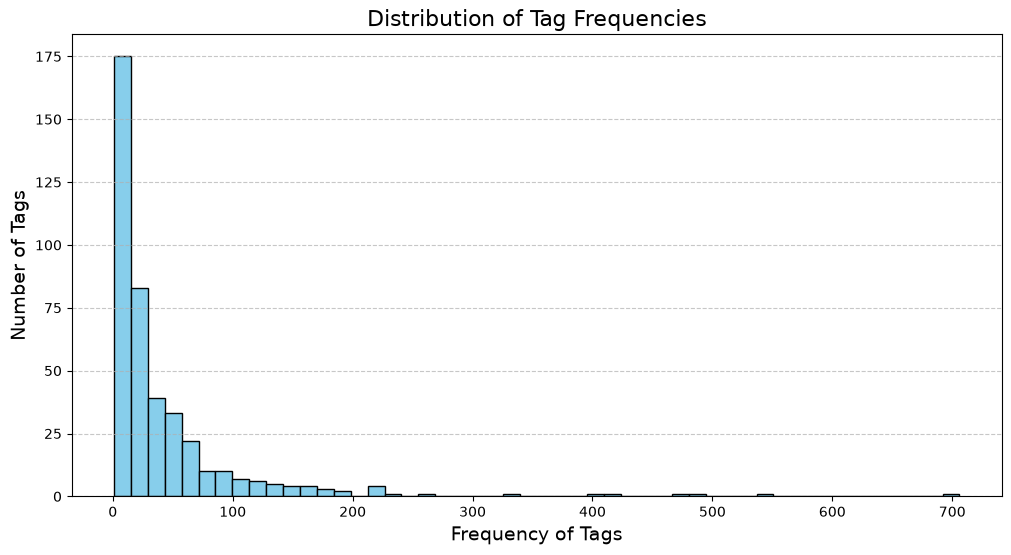

In [49]:
# Histogram: x = how many talks use a tag, y = how many tags have that frequency.
# Most bars sit on the far left -> the "long tail": many rare tags, few very common ones.
plt.figure(figsize=(12, 6))
plt.hist(tag_counts, bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution of Tag Frequencies", fontsize=16)
plt.xlabel("Frequency of Tags", fontsize=14)
plt.ylabel("Number of Tags", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

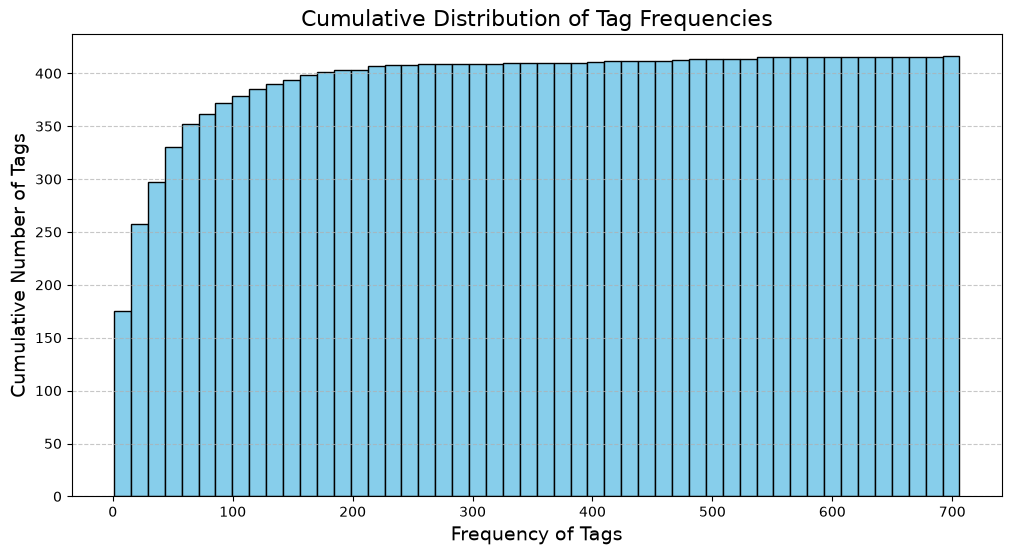

In [50]:
# Same histogram, cumulative: how many tags have a frequency up to x.
plt.figure(figsize=(12, 6))
plt.hist(tag_counts, bins=50, cumulative=True, color="skyblue", edgecolor="black")
plt.title("Cumulative Distribution of Tag Frequencies", fontsize=16)
plt.xlabel("Frequency of Tags", fontsize=14)
plt.ylabel("Cumulative Number of Tags", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

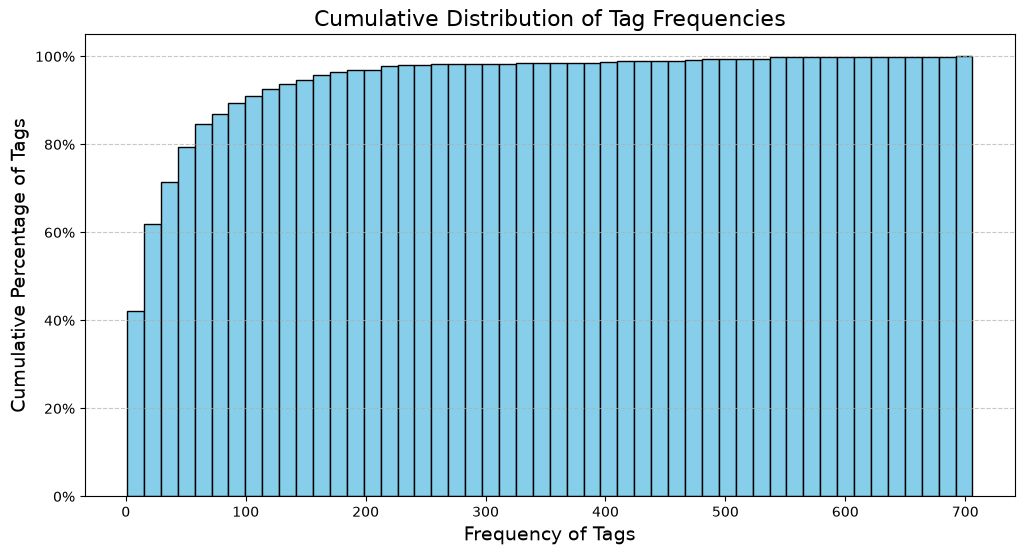

In [51]:
# Same again as a percentage of all tags.
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(12, 6))
plt.hist(tag_counts, bins=50, cumulative=True, density=True, color="skyblue", edgecolor="black")
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.title("Cumulative Distribution of Tag Frequencies", fontsize=16)
plt.xlabel("Frequency of Tags", fontsize=14)
plt.ylabel("Cumulative Percentage of Tags", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [52]:
# share     = this tag's share of all tag assignments
# cum_share = running total, starting from the most common tag
tag_counts_df = pd.DataFrame({
    "tag_counts": tag_counts,
    "share": tag_counts / tag_counts.sum(),
    "cum_share": (tag_counts / tag_counts.sum()).sort_values(ascending=False).cumsum(),
})
tag_counts_df.reset_index(inplace=True)

tag_counts_df.sort_values(by="cum_share", ascending=True)

,tags,tag_counts,share,cum_share
363,technology,706,0.038311,0.038311
320,science,547,0.029683,0.067994
158,global issues,489,0.026536,0.094530
90,culture,468,0.025396,0.119926
373,tedx,417,0.022629,0.142555
...,...,...,...,...
267,origami,1,0.000054,0.999783
331,skateboarding,1,0.000054,0.999837
379,testing,1,0.000054,0.999891
68,cloud,1,0.000054,0.999946


In [53]:
print("Tags that cover 80% of all tag assignments:", tag_counts_df[tag_counts_df["cum_share"] <= 0.8].shape[0])
print("Tags used in at least 10 talks:", tag_counts_df[tag_counts_df["tag_counts"] >= 10].shape[0])

Tags that cover 80% of all tag assignments: 143
Tags used in at least 10 talks: 315


In [54]:
# What happens if we keep only tags used in >= 10 talks?
MIN_TAG_FREQ = 10
kept_tags = set(tag_counts[tag_counts >= MIN_TAG_FREQ].index)

coverage = tag_counts[tag_counts >= MIN_TAG_FREQ].sum() / tag_counts.sum()
talks_left_without_tags = (df["tags"].map(lambda tags: len([t for t in tags if t in kept_tags])) == 0).sum()

print(f"Tags kept: {len(kept_tags)} of {len(tag_counts)}")
print(f"Share of all tag assignments still covered: {coverage:.1%}")
print(f"Talks that would lose all their tags: {talks_left_without_tags}")

Tags kept: 315 of 416
Share of all tag assignments still covered: 97.0%
Talks that would lose all their tags: 0


In [55]:
# Some tags describe the TED event or programme, not the subject of the talk (e.g. 'tedx').
# A model could learn them from the event name instead of the content, so they are not real subject terms.
tag_counts[tag_counts.index.str.contains("ted")]

tags
tedx                 417
ted fellows          137
ted brain trust       45
united states         30
ted prize             26
tedyouth              21
tedmed                19
tednyc                18
ted books             17
ted en español        12
ted residency          6
augmented reality      2
ted-ed                 2
Name: count, dtype: int64

**Findings**
- Each talk has 1–32 tags (median 6). 416 unique tags with a clear long tail: 101 tags are used in fewer than 10 talks.
- Keeping tags with at least 10 talks leaves **315 tags** that still cover **~97% of all tag assignments**, and no talk loses all its tags.
- 11 tags are TED event/programme labels, not subjects: `tedx`, `ted fellows`, `ted brain trust`, `ted prize`, `tedyouth`, `tedmed`, `tednyc`, `ted books`, `ted en español`, `ted residency`, `ted-ed`. `tedx` alone is the 5th most common tag.

**Decision**
- Vocabulary = tags used in **≥ 10 talks**, **minus the TED event/programme tags** (applied in Phase 1, not in `prepare_data`).

## 3. Talks over time: for the train/validation/test split

We plan to split by `published_date` (oldest talks for training, newest for testing) because the real system will tag *future* deposits.
Here we check how talks are spread over the years and whether some tags only appear recently.

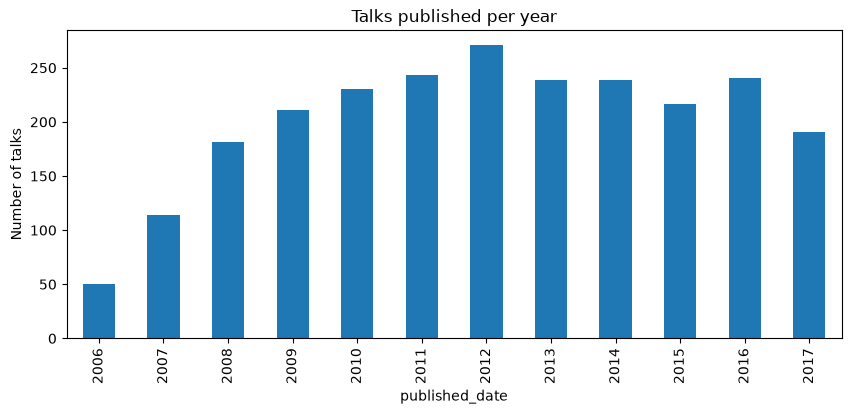

In [56]:
# Number of talks published per year
df["published_date"].dt.year.value_counts().sort_index().plot(kind="bar", figsize=(10, 4), title="Talks published per year")
plt.ylabel("Number of talks")
plt.show()

In [57]:
# For each tag, the year it first appears
tag_years = df[["published_date", "tags"]].explode("tags")
first_year = tag_years.groupby("tags")["published_date"].min().dt.year
print("Tags that first appear in 2015 or later:")
print(sorted(first_year[first_year >= 2015].index))

Tags that first appear in 2015 or later:
['addiction', 'biosphere', 'blockchain', 'capitalism', 'crispr', 'discovery', 'epidemiology', 'funny', 'grammar', 'refugees', 'resources', 'ted residency', 'ted-ed', 'tednyc', 'urban', 'vulnerability']


In [58]:
# Preview of a 70/15/15 time-based split: how many test tag uses were never seen in training?
sorted_df = df.sort_values("published_date")
n = len(sorted_df)
train = sorted_df.iloc[: int(0.70 * n)]
test = sorted_df.iloc[int(0.85 * n):]

train_tags = set(train["tags"].explode())
test_tag_uses = test["tags"].explode()
unseen = test_tag_uses[~test_tag_uses.isin(train_tags)]

print("Train ends:", train["published_date"].max().date(), "| Test starts:", test["published_date"].min().date())
print(f"Test tag uses unseen in training: {len(unseen)} of {len(test_tag_uses)} ({len(unseen) / len(test_tag_uses):.1%})")
print("Unseen tags:", sorted(unseen.unique()))

Train ends: 2014-08-26 | Test starts: 2016-04-06
Test tag uses unseen in training: 102 of 4601 (2.2%)
Unseen tags: ['addiction', 'biosphere', 'blockchain', 'capitalism', 'crispr', 'discovery', 'epidemiology', 'funny', 'grammar', 'refugees', 'resources', 'ted books', 'ted residency', 'ted-ed', 'tednyc', 'television', 'urban', 'vulnerability']


**Findings**
- Talks were published from June 2006 to September 2017, roughly 200–270 per year from 2008 on (fewer in 2006–2007). Some talks were *filmed* much earlier (back to 1984).
- 16 tags first appear in 2015 or later (e.g. `blockchain`, `crispr`, `refugees`, `addiction`).
- With a 70/15/15 time split, train ends Aug 2014 and test starts Apr 2016. Only **~2% of test tag uses** were never seen in training, and most of those tags are rare anyway.

**Decision**
- Use a **time-based 70/15/15 split** on `published_date` (Step 8). Report the small share of unseen tags as a known limitation.

## 4. Transcript length: for the LLM and embedding phases

Rough rule: 1 word ≈ 1.3 tokens. Does a whole transcript fit in the model's input limit, or does it need to be cut into chunks?

**Decision to make:** whether to chunk transcripts.

In [59]:
df["n_words"] = df["transcript"].str.split().str.len()   # words per transcript
df["n_words"].describe()

count    2427.000000
mean     2069.345694
std       934.361487
min       309.000000
25%      1379.500000
50%      2055.000000
75%      2712.000000
max      9055.000000
Name: n_words, dtype: float64

In [60]:
# Transcripts under 300 words were mostly music/performances. prepare_data already removes them,
# so this should now return 0 rows (a quick check that the filter worked).
df[df["n_words"] < 300][["title", "event", "n_words", "tags", "transcript"]].sort_values("n_words").shape

(0, 5)

In [61]:
# Approximate tokens and compare with typical model limits
df["n_tokens_est"] = (df["n_words"] * 1.3).round()
print(df["n_tokens_est"].describe())
print(f"Share over 512 tokens (typical embedding-model limit): {(df['n_tokens_est'] > 512).mean():.0%}")
print(f"Share over 16k tokens (LLM context we will set in Ollama): {(df['n_tokens_est'] > 16_000).mean():.0%}")

count     2427.000000
mean      2690.158632
std       1214.662193
min        402.000000
25%       1793.500000
50%       2672.000000
75%       3526.000000
max      11772.000000
Name: n_tokens_est, dtype: float64
Share over 512 tokens (typical embedding-model limit): 99%
Share over 16k tokens (LLM context we will set in Ollama): 0%


**Findings**
- Transcripts have 310–9,044 words (median ~2,060), i.e. roughly 2,700 tokens for a typical talk and ~12,000 for the longest.
- Every transcript is longer than an embedding model's ~512-token limit, but all fit in a 16k-token LLM context.

**Decision**
- Keep **full transcripts** in `talks.parquet`.
- Phases 1–2 (TF-IDF/Annif, LLM with `num_ctx` ≈ 16k): use the whole transcript, **no chunking**.
- Phases 3–4 (thematic coding, embeddings, passage search): **chunk into ~250-word overlapping segments** inside those phases.

## 5. Description and speaker occupation: the "gold" fields for Phase 2

How long are descriptions? How many distinct occupations are there, and how messy are they?

In [62]:
# Description length in words (the description is TED's own short abstract)
df["description"].str.split().str.len().describe()

count    2427.000000
mean       52.555418
std        18.097898
min        11.000000
25%        39.000000
50%        50.000000
75%        64.000000
max       130.000000
Name: description, dtype: float64

In [63]:
# Raw occupation strings, most common first
df["speaker_occupation"].value_counts().head(20)

speaker_occupation
Writer                                  45
Artist                                  34
Journalist                              32
Designer                                31
Entrepreneur                            30
Architect                               28
Inventor                                27
Psychologist                            26
Photographer                            24
Filmmaker                               21
Economist                               20
Educator                                19
Neuroscientist                          19
Author                                  18
Biologist                               15
Philosopher                             15
Roboticist                              15
Physicist                               12
Global health expert; data visionary    10
Technologist                            10
Name: count, dtype: int64

In [64]:
# Cleaned version: each speaker's occupation split into a list of roles (built in prepare_data)
print(df["occupations"].value_counts().head(30).to_string())

occupations
[writer]                  45
[artist]                  34
[journalist]              32
[designer]                31
[entrepreneur]            30
[architect]               28
[inventor]                27
[psychologist]            26
[photographer]            24
[filmmaker]               21
[economist]               20
[neuroscientist]          20
[roboticist]              19
[educator]                19
[author]                  18
[physicist]               16
[biologist]               15
[philosopher]             15
[graphic designer]        10
[technologist]            10
[activist]                 9
[marine biologist]         9
[historian]                9
[philanthropist]           9
[astronomer]               9
[behavioral economist]     9
[poet]                     9
[futurist]                 8
[novelist]                 8
[oceanographer]            8


In [65]:
print("Unique raw occupation strings:", df["speaker_occupation"].nunique())
print("Unique single roles after splitting:", df["occupations"].explode().nunique())
print(f"Speakers with more than one role: {(df['occupations'].map(len) > 1).mean():.0%}")
print("Talks with more than one speaker:", (df["num_speaker"] > 1).sum())

Unique raw occupation strings: 1403
Unique single roles after splitting: 1247
Speakers with more than one role: 21%
Talks with more than one speaker: 43


**Findings**
- Descriptions are short abstracts: 11–130 words (median ~50).
- `speaker_occupation` is very varied: 1,403 unique strings, 1,247 unique roles after splitting. About **21%** of speakers list several roles (e.g. "Biologist, Nobel laureate") — these are one speaker with several roles, not several speakers (only 43 talks have more than one speaker).
- Synonyms are common ("writer" vs "author"), so exact string matching would be unfair.

**Decision**
- Use the `occupations` list as gold for Phase 2. A predicted role counts as correct if it matches **any** listed role (with lenient/semantic matching for synonyms).
- Use `description` as the reference abstract when evaluating LLM-generated summaries.

## 6. Pick a subset for Phase 3 (thematic coding)

We want one topic with about 80–150 talks: big enough to find several themes, small enough to read and hand-code.

**Decision to make:** which topic to use for thematic coding.

In [66]:
# The least frequent tag above each size threshold (a quick way to see tags of a given size)
print(tag_counts[tag_counts >= 90].sort_values(ascending=True).head(1).index[0])
print(tag_counts[tag_counts >= 100].sort_values(ascending=True).head(1).index[0])
print(tag_counts[tag_counts >= 120].sort_values(ascending=True).head(1).index[0])
print(tag_counts[tag_counts >= 140].sort_values(ascending=True).head(1).index[0])

photography
life
politics
history


In [67]:
# All subject tags in the 80–150 range, so we can choose by topic rather than by size alone
candidates = tag_counts[(tag_counts >= 80) & (tag_counts <= 150)]
candidates[~candidates.index.str.contains("ted")]

tags
community           147
education           146
history             141
invention           139
children            137
health care         132
politics            126
cities              118
women               117
psychology          116
storytelling        115
nature              114
identity            113
war                 110
computers           109
animals             109
engineering         106
africa              101
life                101
music                98
humor                98
exploration          98
personal growth      95
inequality           94
data                 92
government           91
medical research     91
photography          90
neuroscience         87
climate change       85
visualizations       80
architecture         80
Name: count, dtype: int64

**Findings**
- Several subject tags fall in the 80–150 range, e.g. `education` (146), `history` (141), `children` (137), `politics` (126), `cities` (118), `women` (117), `psychology` (116), `war` (110), `africa` (101).

**Decision**
- Use **`education`** (146 talks) for Phase 3: the right size, and a typical social-science topic like the qualitative studies in the UK Data Archive.

## 7. Related talks: the ground truth for Phase 4 ("similar talks")

Does almost every talk have related talks?

In [68]:
# Number of related talks per talk (after removing links to talks we dropped)
df["related_talk_ids"].map(len).describe()

count    2427.000000
mean        5.913885
std         0.336684
min         3.000000
25%         6.000000
50%         6.000000
75%         6.000000
max         6.000000
Name: related_talk_ids, dtype: float64

**Findings**
- Every talk has 3–6 related talks (93% have exactly 6), all pointing to talks that are still in the dataset.

**Decision**
- Use `related_talk_ids` as relevance labels to evaluate "similar talks" in Phase 4. They were chosen by TED, not by us, so they are a reasonable but imperfect ground truth.

## 8. Read some transcripts

Nothing replaces reading the actual text. Look at style, structure and anything odd.

In [69]:
# Read the start of a few talks (change the index to read others)
for i in [0, 500, 1500]:
    print(df.loc[i, "title"], "\n")
    print(df.loc[i, "transcript"][:1500], "\n", 80 * "-")

Do schools kill creativity? 

Good morning. How are you? It's been great, hasn't it? I've been blown away by the whole thing. In fact, I'm leaving. There have been three themes running through the conference which are relevant to what I want to talk about. One is the extraordinary evidence of human creativity in all of the presentations that we've had and in all of the people here. Just the variety of it and the range of it. The second is that it's put us in a place where we have no idea what's going to happen, in terms of the future. No idea how this may play out.I have an interest in education. Actually, what I find is everybody has an interest in education. Don't you? I find this very interesting. If you're at a dinner party, and you say you work in education — Actually, you're not often at dinner parties, frankly. If you work in education, you're not asked. And you're never asked back, curiously. That's strange to me. But if you are, and you say to somebody, you know, they say, "Wh

In [70]:
# Brackets still left after cleaning: only notes with a colon, which are mostly real speech
remaining = df["transcript"].str.findall(r"\([^)]{0,60}\)").explode().dropna()
print("Remaining bracketed notes:", len(remaining))
remaining.value_counts().head(10)

Remaining bracketed notes: 199


transcript
(Audience: Yes.)                      6
(Audio: Laughing)                     6
(Music: "Mary Had a Little Lamb")     5
(Music: "Flight of the Bumblebee")    3
(Audience: Diamonds.)                 2
(Audience: Ten of diamonds.)          2
(Audience: Five of clubs.)            2
(Audience: Stop.)                     2
(Audience: Queen of hearts.)          2
(Audience: Armani.)                   2
Name: count, dtype: int64

In [71]:
# In the raw data, paragraph breaks were lost, so sentences were glued together: "play out.I have".
# prepare_data now restores them, so this check should print 0.
# Count places where a lowercase letter + . ? ! is directly followed by a capital letter.
glued = df["transcript"].str.count(r"[a-z][.?!][A-Z]")
print(f"Talks with glued sentences: {(glued > 0).mean():.0%}, total occurrences: {glued.sum()}")

Talks with glued sentences: 98%, total occurrences: 40499


**Findings**
- Transcripts are spoken monologues: one main speaker, informal style, no speaker labels.
- **Paragraph breaks were lost in the raw data**, so sentences are glued together ("play out.I have"): ~40,000 places in 98% of talks. These glue points are the original paragraph boundaries.
- The raw text had ~790 kinds of sound notes such as (Laughter) ×10k and (Applause) ×5k. `prepare_data` removes bracketed notes without a colon.
- 199 bracketed notes with a colon remain. Most are real speech (e.g. "(Audience: Yes.)"); a few are sounds like "(Music: ...)". This is small enough to accept.

**Decision**
- `prepare_data` turns each glue point back into a paragraph break (`restore_paragraphs`). This fixes the spacing and gives ~18 natural paragraphs per talk for chunking in Phase 3.

## 9. Bias and limits

What kinds of talks dominate, and how might that bias our models?

In [72]:
print(df["event"].value_counts().head(15))
print(f"\nTalks from TEDx events: {df['event'].str.startswith('TEDx').mean():.0%}")
print(f"Talks from TEDGlobal events: {df['event'].str.contains('Global').mean():.0%}")

event
TED2014           84
TED2009           78
TED2013           76
TED2016           73
TED2015           72
TED2011           69
TEDGlobal 2012    68
TED2010           67
TEDGlobal 2011    67
TED2007           66
TEDGlobal 2013    66
TED2017           66
TED2012           63
TEDGlobal 2009    62
TEDGlobal 2010    54
Name: count, dtype: int64

Talks from TEDx events: 18%
Talks from TEDGlobal events: 19%


In [73]:
# 'languages' = number of languages the talk was translated into (the transcripts themselves are all English)
df["languages"].describe()

count    2427.000000
mean       28.176761
std         8.196554
min         1.000000
25%        23.000000
50%        28.000000
75%        33.000000
max        72.000000
Name: languages, dtype: float64

**Findings**
- Mostly main TED conferences (TED2007–TED2017, TEDGlobal); about 18% are TEDx talks.
- All transcripts are in English; `languages` only counts translations.
- Speakers and topics lean towards the US/Europe, technology, science and business. Data covers 2006–2017 only.

**Implications**
- Models and themes will reflect this English, Western, tech-leaning view. Report this as a limitation, and don't assume results transfer directly to UK social-science interview data.

## Summary of decisions

| Topic | Decision |
|---|---|
| Short / missing transcripts | Removed talks without a transcript or with < 300 words (2,550 → 2,427) |
| Sound notes | Removed bracketed notes without a colon, e.g. (Laughter) |
| Glued sentences | Restored lost paragraph breaks in `prepare_data` |
| Tag vocabulary | Tags used in ≥ 10 talks, minus TED event/programme tags |
| Data split | Time-based 70/15/15 on `published_date` |
| Chunking | Whole transcripts in Phases 1–2; ~250-word overlapping chunks in Phases 3–4 |
| Occupation gold | `occupations` list; match any role, lenient matching |
| Phase 3 subset | Talks tagged `education` (146) |
| Similar-talks gold | `related_talk_ids` |